## Install Required Libraries



In [1]:
# Cell 1: Install required libraries
!pip install gradio scikit-image einops timm --quiet
print("All libraries installed successfully!")

All libraries installed successfully!


## Import All Libraries



In [2]:
# Cell 2: Import all required libraries
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

# Torchvision
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# Metrics
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# ── Reproducibility ──────────────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ── Device Setup ─────────────────────────────────────────────────────────────
if torch.cuda.device_count() >= 2:
    device = torch.device('cuda')
    USE_MULTI_GPU = True
    print(f"Using {torch.cuda.device_count()} GPUs (DataParallel)")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    USE_MULTI_GPU = False
    print(f"Using single GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    USE_MULTI_GPU = False
    print("CUDA not available — using CPU (training will be slow)")

print(f"PyTorch version : {torch.__version__}")
print(f"Device selected : {device}")
if torch.cuda.is_available():
    print(f"GPU Memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using 2 GPUs (DataParallel)
PyTorch version : 2.9.0+cu126
Device selected : cuda
GPU Memory      : 15.6 GB


## Global Configuration



In [3]:
# Cell 3: Global Configuration

# ── Image / Patch Settings ────────────────────────────────────────────────────
IMG_SIZE    = 224        # Input image resolution (224×224)
PATCH_SIZE  = 16         # Each patch is 16×16 pixels
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2   # = 196 total patches
MASK_RATIO  = 0.75       # Mask 75% → keep 25% visible
NUM_VISIBLE = int(NUM_PATCHES * (1 - MASK_RATIO))   # = 49 visible patches
NUM_MASKED  = NUM_PATCHES - NUM_VISIBLE              # = 147 masked patches

# ── Encoder (ViT-Base B/16) ───────────────────────────────────────────────────
ENC_DIM     = 768        # Hidden dimension
ENC_DEPTH   = 12         # Number of transformer blocks
ENC_HEADS   = 12         # Multi-head attention heads
ENC_MLP_RATIO = 4.0      # MLP expansion ratio

# ── Decoder (ViT-Small S/16) ──────────────────────────────────────────────────
DEC_DIM     = 384        # Hidden dimension
DEC_DEPTH   = 12         # Number of transformer blocks
DEC_HEADS   = 6          # Multi-head attention heads
DEC_MLP_RATIO = 4.0

# ── Training Hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE    = 32       # Per GPU batch size
EPOCHS        = 3       # Total training epochs
BASE_LR       = 1.5e-4   # Base learning rate
WEIGHT_DECAY  = 0.05     # AdamW weight decay
WARMUP_EPOCHS = 5        # LR warmup epochs
GRAD_CLIP     = 1.0      # Gradient clipping value

# ── Dataset Path ─────────────────────────────────────────────────────────────
DATA_ROOT = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'

# ── Output Directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = '/kaggle/working/mae_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Print Summary ─────────────────────────────────────────────────────────────
print("=" * 50)
print("       MAE Configuration Summary")
print("=" * 50)
print(f"  Image Size      : {IMG_SIZE}×{IMG_SIZE}")
print(f"  Patch Size      : {PATCH_SIZE}×{PATCH_SIZE}")
print(f"  Total Patches   : {NUM_PATCHES}")
print(f"  Mask Ratio      : {MASK_RATIO*100:.0f}%")
print(f"  Visible Patches : {NUM_VISIBLE}")
print(f"  Masked Patches  : {NUM_MASKED}")
print("-" * 50)
print(f"  Encoder Dim     : {ENC_DIM}")
print(f"  Encoder Depth   : {ENC_DEPTH} layers")
print(f"  Decoder Dim     : {DEC_DIM}")
print(f"  Decoder Depth   : {DEC_DEPTH} layers")
print("-" * 50)
print(f"  Batch Size      : {BATCH_SIZE}")
print(f"  Epochs          : {EPOCHS}")
print(f"  Learning Rate   : {BASE_LR}")
print("=" * 50)

       MAE Configuration Summary
  Image Size      : 224×224
  Patch Size      : 16×16
  Total Patches   : 196
  Mask Ratio      : 75%
  Visible Patches : 49
  Masked Patches  : 147
--------------------------------------------------
  Encoder Dim     : 768
  Encoder Depth   : 12 layers
  Decoder Dim     : 384
  Decoder Depth   : 12 layers
--------------------------------------------------
  Batch Size      : 32
  Epochs          : 3
  Learning Rate   : 0.00015


## Dataset Loading — TinyImageNet



In [4]:
import os
import shutil
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

DATA_ROOT = '/kaggle/working/tiny-imagenet-200'

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=train_transform)
val_dataset   = ImageFolder(os.path.join(DATA_ROOT, 'val'),   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val samples   : {len(val_dataset):,}")
print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")

sample_imgs, _ = next(iter(train_loader))
print(f"Sample batch shape : {sample_imgs.shape}")
print("Dataset loading complete!")

Train samples : 100,000
Val samples   : 10,000
Train batches : 3,125
Val batches   : 313
Sample batch shape : torch.Size([32, 3, 224, 224])
Dataset loading complete!


## Patchification & Masking Functions





In [5]:
# Cell 5: Patchification & Masking Functions

def patchify(imgs, patch_size=PATCH_SIZE):
    """
    Split images into non-overlapping patches.
    
    Input  : imgs  → (B, 3, H, W)
    Output : patches → (B, num_patches, patch_size² × 3)
    """
    B, C, H, W = imgs.shape
    p  = patch_size
    h  = H // p   # number of patches along height = 14
    w  = W // p   # number of patches along width  = 14

    # Reshape: (B, C, h, p, w, p) → (B, h*w, p*p*C)
    x = imgs.reshape(B, C, h, p, w, p)
    x = x.permute(0, 2, 4, 3, 5, 1)   # (B, h, w, p, p, C)
    x = x.reshape(B, h * w, p * p * C) # (B, num_patches, patch_dim)
    return x


def unpatchify(patches, patch_size=PATCH_SIZE, img_size=IMG_SIZE):
    """
    Reconstruct images from patches.
    
    Input  : patches → (B, num_patches, patch_size² × 3)
    Output : imgs    → (B, 3, H, W)
    """
    B, N, D = patches.shape
    p = patch_size
    C = D // (p * p)          # = 3
    h = w = img_size // p     # = 14

    x = patches.reshape(B, h, w, p, p, C)
    x = x.permute(0, 5, 1, 3, 2, 4)   # (B, C, h, p, w, p)
    x = x.reshape(B, C, h * p, w * p) # (B, C, H, W)
    return x


def random_masking(x, mask_ratio=MASK_RATIO):
    """
    Randomly mask patches and return visible tokens + mask info.
    
    Args:
        x          : (B, N, D) — all patch tokens
        mask_ratio : fraction to mask (0.75)
    
    Returns:
        x_visible     : (B, num_visible, D) — only visible patches
        mask          : (B, N) — 1=masked, 0=visible (boolean)
        ids_restore   : (B, N) — indices to restore original order
        ids_visible   : (B, num_visible) — indices of visible patches
    """
    B, N, D = x.shape
    num_keep = int(N * (1 - mask_ratio))   # 49

    # Generate random noise to shuffle patches
    noise = torch.rand(B, N, device=x.device)   # uniform [0,1]

    # Sort by noise: first `num_keep` indices are the visible ones
    ids_shuffle = torch.argsort(noise, dim=1)         # (B, N)
    ids_restore = torch.argsort(ids_shuffle, dim=1)   # inverse permutation

    # Keep only the first num_keep tokens
    ids_visible = ids_shuffle[:, :num_keep]           # (B, 49)

    # Gather visible patches
    x_visible = torch.gather(
        x, dim=1,
        index=ids_visible.unsqueeze(-1).expand(-1, -1, D)
    )  # (B, 49, D)

    # Build binary mask: 0=visible, 1=masked
    mask = torch.ones(B, N, device=x.device)
    mask[:, :num_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)   # restore original order

    return x_visible, mask, ids_restore, ids_visible


# ── Quick Sanity Check ────────────────────────────────────────────────────────
print("Running patchify/masking sanity check...")
dummy = torch.randn(4, 3, 224, 224)  # batch of 4 images

patches = patchify(dummy)
print(f"\n patchify output shape       : {patches.shape}")
print(f"   Expected: (4, 196, 768)")

x_vis, mask, ids_restore, ids_vis = random_masking(patches)
print(f"\n  Visible patches shape       : {x_vis.shape}")
print(f"   Expected: (4, 49, 768)")
print(f"\n Mask shape                   : {mask.shape}")
print(f"   Masked count (should be 147) : {mask[0].sum().int().item()}")

recon = unpatchify(patches)
print(f"\n unpatchify output shape      : {recon.shape}")
print(f"   Expected: (4, 3, 224, 224)")
print("\n All shape checks passed!")

Running patchify/masking sanity check...

 patchify output shape       : torch.Size([4, 196, 768])
   Expected: (4, 196, 768)

  Visible patches shape       : torch.Size([4, 49, 768])
   Expected: (4, 49, 768)

 Mask shape                   : torch.Size([4, 196])
   Masked count (should be 147) : 147

 unpatchify output shape      : torch.Size([4, 3, 224, 224])
   Expected: (4, 3, 224, 224)

 All shape checks passed!


##  Building Blocks — Transformer Components



In [6]:
# Cell 6: Transformer Building Blocks

class MultiHeadSelfAttention(nn.Module):
    """
    Standard Multi-Head Self-Attention.
    Each token attends to every other token in the sequence.
    """
    def __init__(self, dim, num_heads, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5   # 1/√d_k for stable gradients

        # Combined Q, K, V projection (3× dim output)
        self.qkv     = nn.Linear(dim, dim * 3, bias=True)
        self.proj    = nn.Linear(dim, dim)       # output projection
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape

        # Project to Q, K, V
        qkv = self.qkv(x)                              # (B, N, 3C)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)              # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)                        # each: (B, heads, N, head_dim)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)

        # Aggregate values
        x = (attn @ v)                                 # (B, heads, N, head_dim)
        x = x.transpose(1, 2).reshape(B, N, C)        # (B, N, C)
        x = self.proj(x)
        return x


class MLP(nn.Module):
    """Two-layer feed-forward network with GELU activation."""
    def __init__(self, dim, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """
    One Transformer Block = LayerNorm + Attention + LayerNorm + MLP
    Uses Pre-LN (LayerNorm before sublayer) for training stability.
    """
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # residual connection
        x = x + self.mlp(self.norm2(x))    # residual connection
        return x


# Quick test
blk = TransformerBlock(dim=768, num_heads=12)
test_in  = torch.randn(2, 49, 768)
test_out = blk(test_in)
print(f"TransformerBlock test: {test_in.shape} → {test_out.shape}")
print(" Transformer building blocks verified!")

TransformerBlock test: torch.Size([2, 49, 768]) → torch.Size([2, 49, 768])
 Transformer building blocks verified!


##  MAE Encoder (ViT-Base)



In [7]:
# Cell 7: MAE Encoder

class MAEEncoder(nn.Module):
    """
    ViT-Base Encoder for MAE.
    - Accepts ONLY visible patches (25% = 49 patches)
    - Applies patch embedding → positional encoding → transformer layers
    """
    def __init__(
        self,
        img_size    = IMG_SIZE,
        patch_size  = PATCH_SIZE,
        in_channels = 3,
        embed_dim   = ENC_DIM,
        depth       = ENC_DEPTH,
        num_heads   = ENC_HEADS,
        mlp_ratio   = ENC_MLP_RATIO,
        mask_ratio  = MASK_RATIO,
    ):
        super().__init__()
        self.patch_size  = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.embed_dim   = embed_dim
        self.mask_ratio  = mask_ratio
        patch_dim        = in_channels * patch_size * patch_size  # 3×16×16 = 768

        # ── Patch Embedding: linear projection of raw patch pixels ───────────
        self.patch_embed = nn.Linear(patch_dim, embed_dim)

        # ── Positional Embedding: fixed sinusoidal (not learned) ─────────────
        # Shape: (1, num_patches, embed_dim)
        pos_embed = self._build_sinusoidal_pos_embed(self.num_patches, embed_dim)
        self.register_buffer('pos_embed', pos_embed)

        # ── Transformer Blocks ────────────────────────────────────────────────
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])

        # ── Final Layer Norm ──────────────────────────────────────────────────
        self.norm = nn.LayerNorm(embed_dim)

        # Initialize weights
        self._init_weights()

    def _build_sinusoidal_pos_embed(self, num_patches, embed_dim):
        """Build 1D sinusoidal positional embeddings."""
        pos    = torch.arange(num_patches).unsqueeze(1).float()
        dim_i  = torch.arange(embed_dim // 2).unsqueeze(0).float()
        theta  = pos / (10000 ** (2 * dim_i / embed_dim))
        pe     = torch.zeros(num_patches, embed_dim)
        pe[:, 0::2] = torch.sin(theta)
        pe[:, 1::2] = torch.cos(theta)
        return pe.unsqueeze(0)   # (1, num_patches, embed_dim)

    def _init_weights(self):
        """Initialize linear layers and layer norms."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, imgs):
        """
        Args:
            imgs : (B, 3, H, W)
        Returns:
            latent     : (B, num_visible, embed_dim)
            mask       : (B, num_patches) — 1=masked, 0=visible
            ids_restore: (B, num_patches) — to restore original ordering
        """
        # Step 1: Patchify input images
        x = patchify(imgs)              # (B, 196, 768)

        # Step 2: Linear patch embedding
        x = self.patch_embed(x)         # (B, 196, 768)

        # Step 3: Add positional embeddings (full set)
        x = x + self.pos_embed          # (B, 196, 768)

        # Step 4: Random masking — keep only 25% of patches
        x, mask, ids_restore, ids_visible = random_masking(x, self.mask_ratio)
        # x is now (B, 49, 768)

        # Step 5: Pass ONLY visible tokens through the transformer
        for block in self.blocks:
            x = block(x)                # (B, 49, 768)

        # Step 6: Final normalization
        x = self.norm(x)               # (B, 49, 768)

        return x, mask, ids_restore


# Test encoder
encoder  = MAEEncoder()
dummy_in = torch.randn(2, 3, 224, 224)
lat, msk, idr = encoder(dummy_in)
print(f"Encoder output (latent) : {lat.shape}  ← (B, 49 visible, 768)")
print(f"Mask shape              : {msk.shape}")
print(f"ids_restore shape       : {idr.shape}")

enc_params = sum(p.numel() for p in encoder.parameters()) / 1e6
print(f"\n Encoder parameters : {enc_params:.1f}M  (target ≈ 86M)")
print(" Encoder verified!")

Encoder output (latent) : torch.Size([2, 49, 768])  ← (B, 49 visible, 768)
Mask shape              : torch.Size([2, 196])
ids_restore shape       : torch.Size([2, 196])

 Encoder parameters : 85.6M  (target ≈ 86M)
 Encoder verified!


##  MAE Decoder (ViT-Small)


In [8]:
# Cell 8: MAE Decoder

class MAEDecoder(nn.Module):
    """
    ViT-Small Decoder for MAE.
    - Takes visible latent tokens + learnable mask tokens
    - Reconstructs full 196-patch sequence
    - Outputs pixel values for each patch
    """
    def __init__(
        self,
        num_patches  = NUM_PATCHES,
        patch_size   = PATCH_SIZE,
        in_channels  = 3,
        enc_embed_dim = ENC_DIM,
        embed_dim    = DEC_DIM,
        depth        = DEC_DEPTH,
        num_heads    = DEC_HEADS,
        mlp_ratio    = DEC_MLP_RATIO,
    ):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim   = embed_dim
        patch_dim        = in_channels * patch_size * patch_size  # 768

        # ── Project encoder tokens to decoder dimension ────────────────────────
        self.enc_to_dec = nn.Linear(enc_embed_dim, embed_dim, bias=True)

        # ── Learnable mask token (shared for all masked positions) ─────────────
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

        # ── Positional Embedding (for ALL 196 positions) ───────────────────────
        pos_embed = self._build_sinusoidal_pos_embed(num_patches, embed_dim)
        self.register_buffer('pos_embed', pos_embed)

        # ── Transformer Blocks ─────────────────────────────────────────────────
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])

        # ── Layer Norm ─────────────────────────────────────────────────────────
        self.norm = nn.LayerNorm(embed_dim)

        # ── Prediction Head: decode each token → patch pixel values ───────────
        self.head = nn.Linear(embed_dim, patch_dim)

        self._init_weights()

    def _build_sinusoidal_pos_embed(self, num_patches, embed_dim):
        pos   = torch.arange(num_patches).unsqueeze(1).float()
        dim_i = torch.arange(embed_dim // 2).unsqueeze(0).float()
        theta = pos / (10000 ** (2 * dim_i / embed_dim))
        pe    = torch.zeros(num_patches, embed_dim)
        pe[:, 0::2] = torch.sin(theta)
        pe[:, 1::2] = torch.cos(theta)
        return pe.unsqueeze(0)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, latent, ids_restore):
        """
        Args:
            latent      : (B, 49, 768) — encoder output
            ids_restore : (B, 196)     — to restore original patch order
        Returns:
            pred : (B, 196, 768) — reconstructed patch pixel values
        """
        B = latent.shape[0]

        # Step 1: Project visible tokens 768 → 384
        x = self.enc_to_dec(latent)   # (B, 49, 384)

        # Step 2: Expand mask tokens to fill all missing positions
        num_masked   = self.num_patches - x.shape[1]   # 147
        mask_tokens  = self.mask_token.expand(B, num_masked, -1)   # (B, 147, 384)

        # Step 3: Concatenate visible tokens + mask tokens
        x_full = torch.cat([x, mask_tokens], dim=1)   # (B, 196, 384)

        # Step 4: Unshuffle — restore original spatial ordering
        x_full = torch.gather(
            x_full, dim=1,
            index=ids_restore.unsqueeze(-1).expand(-1, -1, self.embed_dim)
        )  # (B, 196, 384) — patches back in their correct positions

        # Step 5: Add positional embeddings
        x_full = x_full + self.pos_embed   # (B, 196, 384)

        # Step 6: Transformer blocks
        for block in self.blocks:
            x_full = block(x_full)         # (B, 196, 384)

        # Step 7: Layer norm + prediction head
        x_full = self.norm(x_full)         # (B, 196, 384)
        pred   = self.head(x_full)         # (B, 196, 768) — pixel values

        return pred


# Test decoder
decoder  = MAEDecoder()
dummy_lat = torch.randn(2, 49, 768)
dummy_idr = torch.zeros(2, 196, dtype=torch.long)
pred = decoder(dummy_lat, dummy_idr)
print(f"Decoder output : {pred.shape}  ← (B, 196 patches, 768 pixels each)")

dec_params = sum(p.numel() for p in decoder.parameters()) / 1e6
print(f" Decoder parameters : {dec_params:.1f}M  (target ≈ 22M)")
print(" Decoder verified!")

Decoder output : torch.Size([2, 196, 768])  ← (B, 196 patches, 768 pixels each)
 Decoder parameters : 21.9M  (target ≈ 22M)
 Decoder verified!


##  Complete MAE Model



In [9]:
# Cell 9: Complete MAE Model

class MaskedAutoencoder(nn.Module):
    """Complete MAE: Encoder + Decoder + Loss Computation."""

    def __init__(self):
        super().__init__()
        self.encoder = MAEEncoder()
        self.decoder = MAEDecoder()

    def forward(self, imgs):
        """
        Full MAE forward pass.
        
        Args:
            imgs : (B, 3, 224, 224)
        Returns:
            loss     : scalar — MSE on masked patches only
            pred     : (B, 196, 768) — reconstructed patch pixels
            mask     : (B, 196) — 1=masked, 0=visible
        """
        # ── Encoder: extract latent from visible patches ──────────────────────
        latent, mask, ids_restore = self.encoder(imgs)

        # ── Decoder: reconstruct all patches ─────────────────────────────────
        pred = self.decoder(latent, ids_restore)   # (B, 196, 768)

        # ── Target: patchified original image ────────────────────────────────
        target = patchify(imgs)                    # (B, 196, 768)

        # ── MSE Loss on MASKED patches only ──────────────────────────────────
        loss = self.mae_loss(pred, target, mask)

        return loss, pred, mask

    def mae_loss(self, pred, target, mask):
        """
        Compute per-pixel MSE averaged over masked patches only.
        
        mask: 1 = masked (compute loss here), 0 = visible (ignore)
        """
        # Per-pixel squared error
        loss = (pred - target) ** 2          # (B, 196, 768)
        loss = loss.mean(dim=-1)             # (B, 196) — mean over pixels in patch

        # Only count masked patches
        loss = (loss * mask).sum() / mask.sum()
        return loss

    def reconstruct(self, imgs, mask_ratio=None):
        """Reconstruct image for visualization (no gradient needed)."""
        with torch.no_grad():
            loss, pred, mask = self.forward(imgs)

        # Convert predictions back to image space
        pred_img    = unpatchify(pred)         # (B, 3, 224, 224)
        masked_img  = self._make_masked_image(imgs, mask)

        return pred_img, masked_img, mask, loss.item()

    def _make_masked_image(self, imgs, mask):
        """Replace masked patch regions with gray color for visualization."""
        patches = patchify(imgs).clone()       # (B, 196, 768)
        gray_val = -1.0   # approximate gray in normalized space
        mask_exp = mask.unsqueeze(-1).expand_as(patches)  # (B, 196, 768)
        patches  = patches * (1 - mask_exp) + gray_val * mask_exp
        return unpatchify(patches)             # (B, 3, 224, 224)


# Build model
model = MaskedAutoencoder()

# Move to GPU(s)
if USE_MULTI_GPU:
    model = nn.DataParallel(model)
    print(f" Using DataParallel on {torch.cuda.device_count()} GPUs")
model = model.to(device)

# Parameter count
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"\n Total parameters : {total_params:.1f}M")

# Test full forward pass
dummy_imgs = torch.randn(2, 3, 224, 224).to(device)
with torch.no_grad():
    loss_test, pred_test, mask_test = (
        model(dummy_imgs) if not USE_MULTI_GPU else model(dummy_imgs)
    )
print(f"\n Forward pass test:")
print(f"   Loss  : {loss_test.mean().item():.4f}")
print(f"   Pred  : {pred_test.shape}")
print(f"   Mask  : {mask_test.shape}")
print("\n Full MAE model verified!")

 Using DataParallel on 2 GPUs

 Total parameters : 107.5M

 Forward pass test:
   Loss  : 1.6850
   Pred  : torch.Size([2, 196, 768])
   Mask  : torch.Size([2, 196])

 Full MAE model verified!


##  Training Setup (Optimizer, Scheduler, AMP)


In [10]:
# Cell 10: Training Setup

# ── Optimizer: AdamW ──────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = BASE_LR,
    betas        = (0.9, 0.95),   # MAE paper recommends 0.95 for beta2
    weight_decay = WEIGHT_DECAY,
)

# ── LR Scheduler: Linear Warmup + Cosine Decay ───────────────────────────────
total_steps   = EPOCHS * len(train_loader)
warmup_steps  = WARMUP_EPOCHS * len(train_loader)

def lr_lambda(current_step):
    """Linear warmup then cosine decay."""
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Mixed Precision Scaler ────────────────────────────────────────────────────
scaler = GradScaler(enabled=torch.cuda.is_available())

# ── Training History ──────────────────────────────────────────────────────────
history = {
    'train_loss' : [],
    'val_loss'   : [],
    'lr'         : [],
}

print("Training Configuration:")
print(f"  Optimizer     : AdamW (lr={BASE_LR}, wd={WEIGHT_DECAY})")
print(f"  Scheduler     : Warmup {WARMUP_EPOCHS} epochs + Cosine Decay")
print(f"  Total steps   : {total_steps:,}")
print(f"  Warmup steps  : {warmup_steps:,}")
print(f"  Mixed Prec.   : {' Enabled' if torch.cuda.is_available() else ' Disabled (CPU)'}")
print(f"  Grad Clipping : {GRAD_CLIP}")
print("\n Training setup complete!")

Training Configuration:
  Optimizer     : AdamW (lr=0.00015, wd=0.05)
  Scheduler     : Warmup 5 epochs + Cosine Decay
  Total steps   : 9,375
  Warmup steps  : 15,625
  Mixed Prec.   :  Enabled
  Grad Clipping : 1.0

 Training setup complete!


## : Training Loop



In [11]:
# Cell 11: Training Loop

def train_one_epoch(model, loader, optimizer, scaler, scheduler, epoch):
    """Train for one epoch. Returns average loss."""
    model.train()
    total_loss = 0.0
    num_batches = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    for imgs, _ in pbar:
        imgs = imgs.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # ── Mixed precision forward pass ──────────────────────────────────────
        with autocast(enabled=torch.cuda.is_available()):
            loss, _, _ = model(imgs)
            if USE_MULTI_GPU:
                loss = loss.mean()   # Average over GPUs

        # ── Backward pass with gradient scaling ───────────────────────────────
        scaler.scale(loss).backward()

        # ── Gradient clipping ─────────────────────────────────────────────────
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        # ── Optimizer step ────────────────────────────────────────────────────
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss  += loss.item()
        num_batches += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})

    return total_loss / num_batches


@torch.no_grad()
def validate(model, loader, epoch):
    """Validate for one epoch. Returns average loss."""
    model.eval()
    total_loss = 0.0
    num_batches = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  ", leave=False)
    for imgs, _ in pbar:
        imgs = imgs.to(device, non_blocking=True)
        with autocast(enabled=torch.cuda.is_available()):
            loss, _, _ = model(imgs)
            if USE_MULTI_GPU:
                loss = loss.mean()
        total_loss  += loss.item()
        num_batches += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / num_batches


# ── Main Training Loop ────────────────────────────────────────────────────────
best_val_loss  = float('inf')
checkpoint_path = os.path.join(OUTPUT_DIR, 'mae_best.pth')

print("Starting training...")
print("=" * 60)

for epoch in range(EPOCHS):
    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, scheduler, epoch)

    # Validate
    val_loss = validate(model, val_loader, epoch)

    # Get current LR
    current_lr = scheduler.get_last_lr()[0]

    # Log
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(current_lr)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            (model.module if USE_MULTI_GPU else model).state_dict(),
            checkpoint_path
        )
        flag = " ←  best"
    else:
        flag = ""

    print(f"Epoch [{epoch+1:3d}/{EPOCHS}]  "
          f"Train: {train_loss:.4f}  "
          f"Val: {val_loss:.4f}  "
          f"LR: {current_lr:.2e}{flag}")

print("=" * 60)
print(f"\n Training complete! Best val loss: {best_val_loss:.4f}")
print(f"   Checkpoint saved to: {checkpoint_path}")

Starting training...


Epoch [  1/3]  Train: 0.7090  Val: 0.4368  LR: 3.00e-05 ←  best


Epoch [  2/3]  Train: 0.3618  Val: 0.3591  LR: 6.00e-05 ←  best


Epoch [  3/3]  Train: 0.3086  Val: 0.3047  LR: 9.00e-05 ←  best

 Training complete! Best val loss: 0.3047
   Checkpoint saved to: /kaggle/working/mae_outputs/mae_best.pth


##  Plot Training Curves



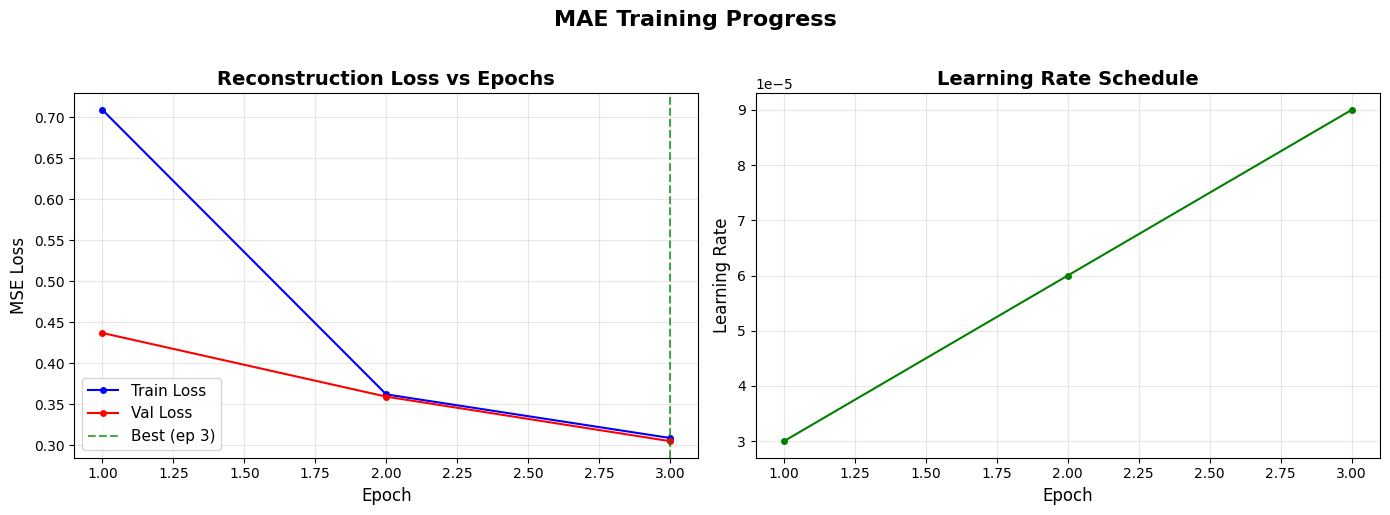

 Training curves saved!


In [12]:
# Cell 12: Plot Training Curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# ── Loss curves ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
ax.plot(epochs_range, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
ax.set_xlabel('Epoch',         fontsize=12)
ax.set_ylabel('MSE Loss',      fontsize=12)
ax.set_title('Reconstruction Loss vs Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
best_ep = history['val_loss'].index(min(history['val_loss'])) + 1
ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best (ep {best_ep})')
ax.legend(fontsize=11)

# ── LR schedule ───────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_range, history['lr'], 'g-o', markersize=4)
ax.set_xlabel('Epoch',         fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

plt.suptitle('MAE Training Progress', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Training curves saved!")

##  Load Best Model & Visualization Helper



In [13]:
# Cell 13: Load Best Model & Visualization Helpers

# Load best checkpoint
core_model = MaskedAutoencoder().to(device)
core_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
core_model.eval()
print(" Best model loaded from checkpoint.")

# ImageNet denormalization
MEAN = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
STD  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denormalize(tensor):
    """Undo ImageNet normalization and clamp to [0, 1]."""
    return torch.clamp(tensor * STD + MEAN, 0.0, 1.0)

def tensor_to_numpy(t):
    """(C, H, W) tensor → (H, W, C) numpy array in [0, 1]."""
    return denormalize(t.cpu()).permute(1, 2, 0).numpy()

print(" Visualization helpers ready.")

 Best model loaded from checkpoint.
 Visualization helpers ready.


##  Qualitative Visualization (5 Samples)



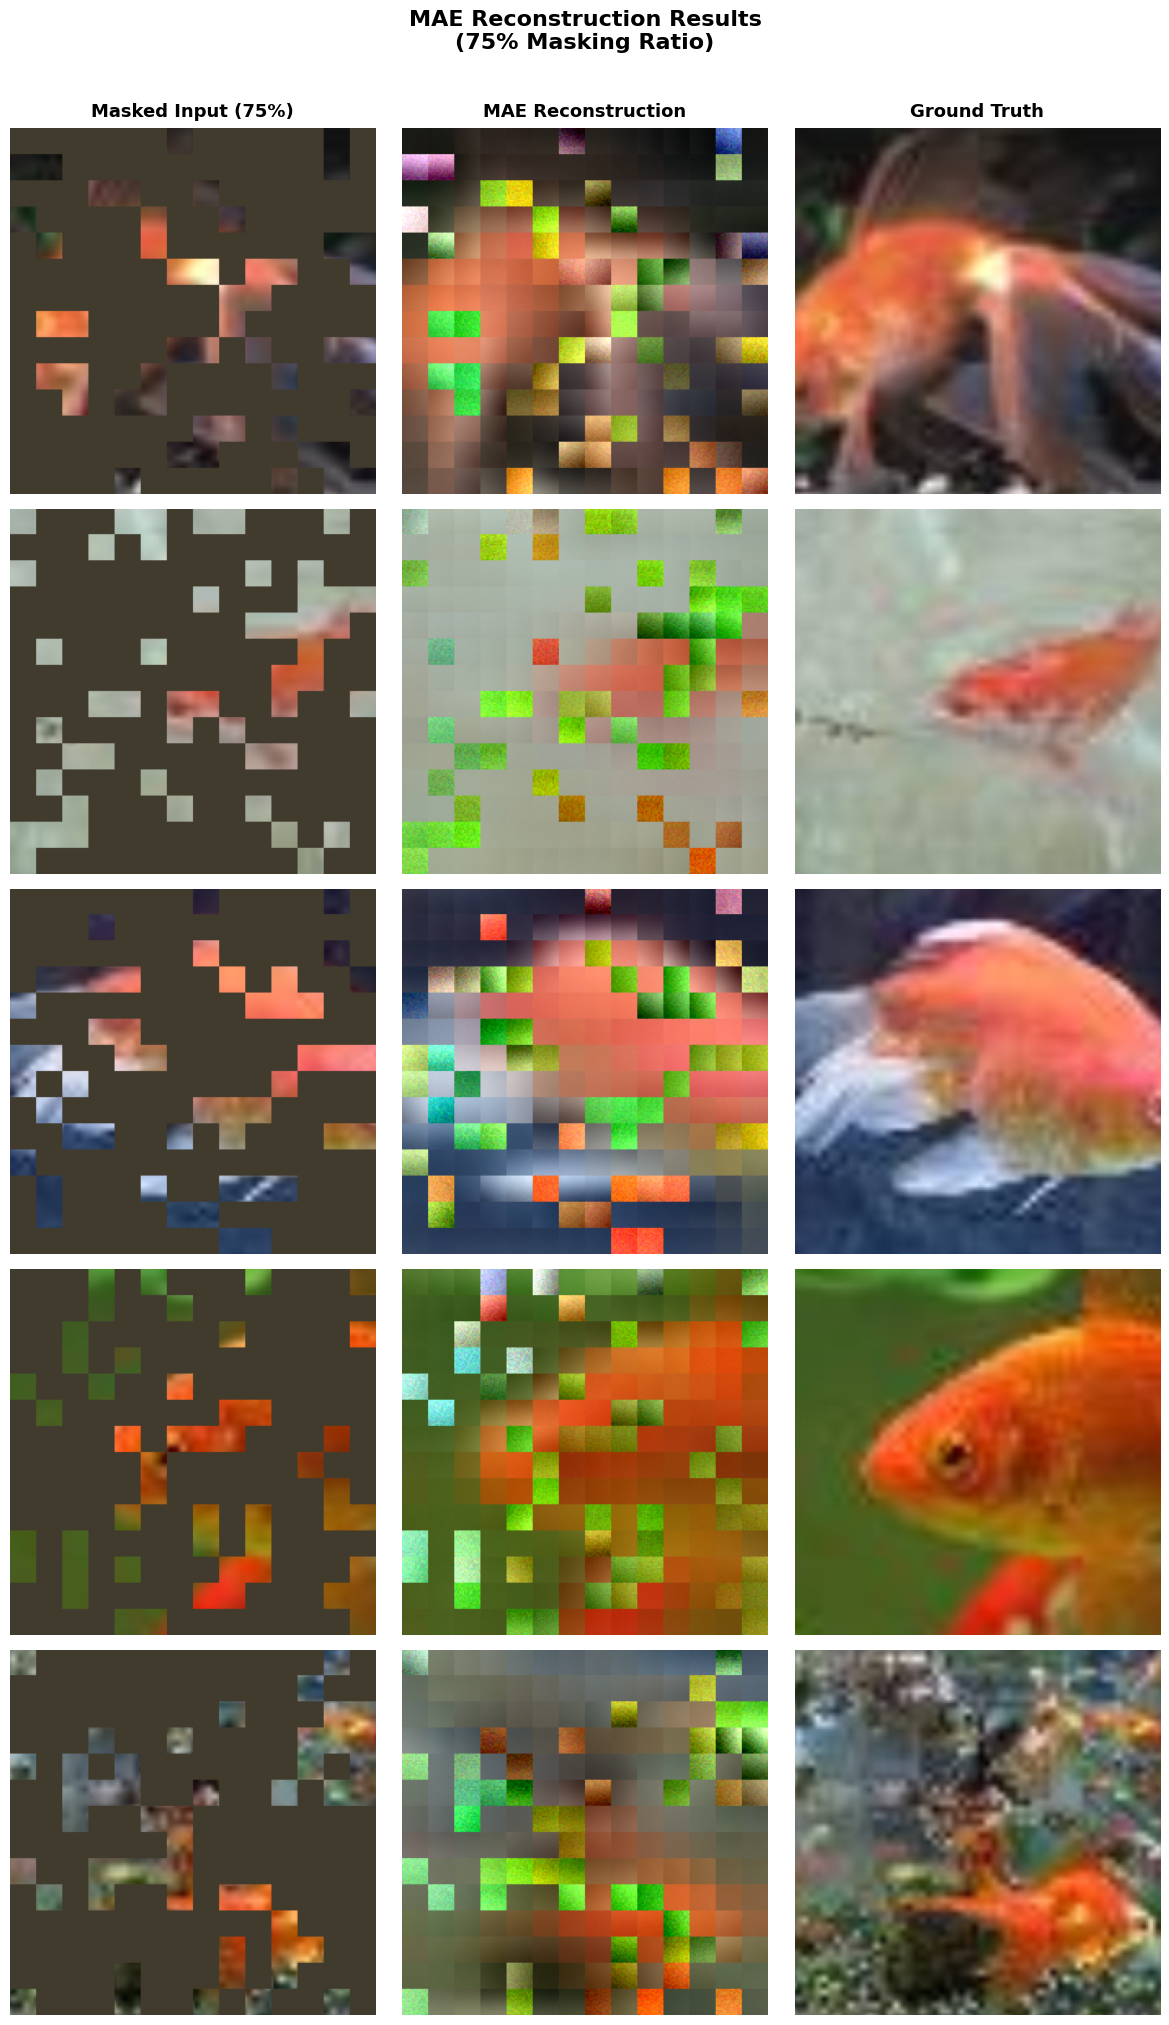

 Reconstruction visualization saved!


In [14]:
# Cell 14: Qualitative Visualization

NUM_VIZ = 5

# Get a batch from the validation loader
val_imgs, _ = next(iter(val_loader))
val_imgs = val_imgs[:NUM_VIZ].to(device)

# Run reconstruction
with torch.no_grad():
    loss_viz, pred_viz, mask_viz = core_model(val_imgs)

# Convert pred patches → image space
recon_imgs  = unpatchify(pred_viz)                             # (5, 3, 224, 224)
masked_imgs = core_model._make_masked_image(val_imgs, mask_viz) # (5, 3, 224, 224)

# Plot
fig, axes = plt.subplots(NUM_VIZ, 3, figsize=(12, 4 * NUM_VIZ))
fig.suptitle('MAE Reconstruction Results\n(75% Masking Ratio)',
             fontsize=16, fontweight='bold', y=1.01)

col_titles = ['Masked Input (75%)', 'MAE Reconstruction', 'Ground Truth']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight='bold', pad=8)

for i in range(NUM_VIZ):
    original = tensor_to_numpy(val_imgs[i].cpu())
    masked   = tensor_to_numpy(masked_imgs[i].cpu())
    recon    = tensor_to_numpy(recon_imgs[i].cpu())

    axes[i, 0].imshow(masked)
    axes[i, 1].imshow(recon)
    axes[i, 2].imshow(original)

    for j in range(3):
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(f'Sample {i+1}', fontsize=11, rotation=90, labelpad=5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'reconstructions.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Reconstruction visualization saved!")

##  Quantitative Evaluation (PSNR & SSIM)



In [15]:
# Cell 15: Quantitative Evaluation

def compute_metrics(original_tensor, recon_tensor):
    """
    Compute PSNR and SSIM between original and reconstructed images.
    
    Args:
        original_tensor : (B, 3, H, W) torch tensor (normalized)
        recon_tensor    : (B, 3, H, W) torch tensor (normalized)
    Returns:
        dict with lists of psnr and ssim values per sample
    """
    results = {'psnr': [], 'ssim': []}
    B = original_tensor.shape[0]

    for i in range(B):
        orig_np  = tensor_to_numpy(original_tensor[i].cpu()).astype(np.float32)
        recon_np = tensor_to_numpy(recon_tensor[i].cpu()).astype(np.float32)

        # PSNR
        psnr_val = psnr_metric(orig_np, recon_np, data_range=1.0)

        # SSIM (channel_axis=2 for H×W×C format)
        ssim_val = ssim_metric(
            orig_np, recon_np,
            data_range=1.0,
            channel_axis=2,
            win_size=7
        )

        results['psnr'].append(psnr_val)
        results['ssim'].append(ssim_val)

    return results


# ── Evaluate on validation set ────────────────────────────────────────────────
all_psnr, all_ssim = [], []
eval_batches = 5   # evaluate on 5 batches for speed

core_model.eval()
with torch.no_grad():
    for batch_idx, (imgs, _) in enumerate(val_loader):
        if batch_idx >= eval_batches:
            break
        imgs = imgs.to(device)
        _, pred, mask = core_model(imgs)
        recon_imgs_eval = unpatchify(pred)
        metrics = compute_metrics(imgs, recon_imgs_eval)
        all_psnr.extend(metrics['psnr'])
        all_ssim.extend(metrics['ssim'])

# ── Print per-sample results for first 5 samples ─────────────────────────────
print("\n" + "=" * 45)
print("       Quantitative Evaluation Results")
print("=" * 45)
print(f"{'Sample':<10} {'PSNR (dB)':<15} {'SSIM':<10}")
print("-" * 45)
for i in range(min(NUM_VIZ, len(all_psnr))):
    print(f"  {i+1:<8} {all_psnr[i]:<15.2f} {all_ssim[i]:<10.4f}")
print("-" * 45)
print(f"  {'Average':<8} {np.mean(all_psnr):<15.2f} {np.mean(all_ssim):<10.4f}")
print(f"  {'Std':<8} {np.std(all_psnr):<15.2f} {np.std(all_ssim):<10.4f}")
print("=" * 45)

print(f"\n Total samples evaluated : {len(all_psnr)}")
print("\n Quantitative evaluation complete!")


       Quantitative Evaluation Results
Sample     PSNR (dB)       SSIM      
---------------------------------------------
  1        13.36           0.4058    
  2        15.80           0.5534    
  3        12.79           0.3876    
  4        15.66           0.4873    
  5        14.90           0.2675    
---------------------------------------------
  Average  14.34           0.3106    
  Std      1.23            0.1056    

 Total samples evaluated : 160

 Quantitative evaluation complete!


##  Metrics Bar Chart



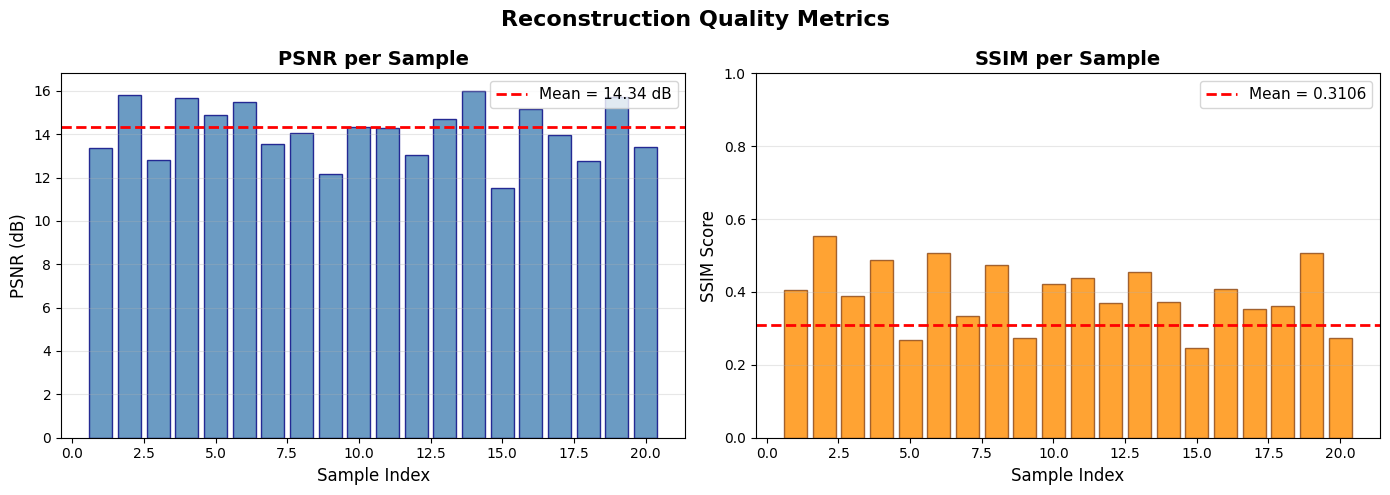

 Metrics chart saved!


In [16]:
# Cell 16: Metrics Bar Chart

n_show  = min(20, len(all_psnr))   # show first 20 samples
samples = list(range(1, n_show + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PSNR
ax = axes[0]
bars = ax.bar(samples, all_psnr[:n_show], color='steelblue', alpha=0.8, edgecolor='navy')
ax.axhline(np.mean(all_psnr), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(all_psnr):.2f} dB')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('PSNR (dB)',    fontsize=12)
ax.set_title('PSNR per Sample', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# SSIM
ax = axes[1]
bars = ax.bar(samples, all_ssim[:n_show], color='darkorange', alpha=0.8, edgecolor='saddlebrown')
ax.axhline(np.mean(all_ssim), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(all_ssim):.4f}')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('SSIM Score',   fontsize=12)
ax.set_title('SSIM per Sample', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Reconstruction Quality Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'metrics_chart.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Metrics chart saved!")

##  Gradio Web App



In [17]:
# Cell 17: Gradio Web App
import gradio as gr

# ── Inference helper that accepts custom mask ratio ───────────────────────────
def mae_inference(pil_image, mask_ratio_pct):
    """
    Run MAE reconstruction on a user-uploaded image.
    
    Args:
        pil_image      : PIL Image uploaded by user
        mask_ratio_pct : masking percentage (0-100)
    Returns:
        masked_pil, recon_pil, original_pil
    """
    mask_ratio = mask_ratio_pct / 100.0

    # Preprocess
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    img_tensor = transform(pil_image.convert('RGB')).unsqueeze(0).to(device)  # (1, 3, 224, 224)

    core_model.eval()
    with torch.no_grad():
        # Temporarily override mask ratio
        original_ratio = core_model.encoder.mask_ratio
        core_model.encoder.mask_ratio = mask_ratio

        loss, pred, mask = core_model(img_tensor)

        core_model.encoder.mask_ratio = original_ratio

    recon_tensor  = unpatchify(pred)                                  # (1, 3, 224, 224)
    masked_tensor = core_model._make_masked_image(img_tensor, mask)   # (1, 3, 224, 224)

    def to_pil(t):
        arr = tensor_to_numpy(t[0])
        return Image.fromarray((arr * 255).astype(np.uint8))

    masked_pil   = to_pil(masked_tensor)
    recon_pil    = to_pil(recon_tensor)
    original_pil = to_pil(img_tensor)

    mse = loss.mean().item()
    info = (
        f"**Mask Ratio:** {mask_ratio_pct:.0f}%  \n"
        f"**Visible Patches:** {int(196*(1-mask_ratio))} / 196  \n"
        f"**Masked Patches:** {int(196*mask_ratio)} / 196  \n"
        f"**Reconstruction MSE Loss:** {mse:.5f}"
    )

    return masked_pil, recon_pil, original_pil, info


# ── Build Gradio Interface ────────────────────────────────────────────────────
with gr.Blocks(title="MAE Image Reconstruction", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🧠 Masked Autoencoder (MAE) — Image Reconstruction
    Upload any image and watch the AI reconstruct it from limited visible patches!
    """)

    with gr.Row():
        with gr.Column(scale=1):
            inp_image  = gr.Image(type='pil', label='📤 Upload Image')
            mask_slider = gr.Slider(
                minimum=10, maximum=90, step=5, value=75,
                label=' Masking Ratio (%)'
            )
            run_btn = gr.Button('🚀 Reconstruct!', variant='primary')
            info_box = gr.Markdown("")

        with gr.Column(scale=3):
            with gr.Row():
                out_masked   = gr.Image(type='pil', label=' Masked Input')
                out_recon    = gr.Image(type='pil', label=' Reconstruction')
                out_original = gr.Image(type='pil', label=' Ground Truth')

    run_btn.click(
        fn=mae_inference,
        inputs=[inp_image, mask_slider],
        outputs=[out_masked, out_recon, out_original, info_box]
    )

    gr.Markdown("""
    ---
    **Model:** ViT-Base Encoder (~86M params) + ViT-Small Decoder (~22M params)  
    **Dataset:** TinyImageNet (200 classes)  
    **Training:** MSE loss on masked patches only
    """)

demo.launch(share=True, debug=False)
print(" Gradio app launched! Click the public URL above to open it.")

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://4e93196e06a8b5965b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


 Gradio app launched! Click the public URL above to open it.


##  Save All Results Summary



In [20]:
# Cell 18: Save Results Summary

summary = f"""
================================================================
          MAE Assignment Results Summary
================================================================

MODEL ARCHITECTURE
------------------
Encoder : ViT-Base (B/16)
  - Patch Size    : {PATCH_SIZE}×{PATCH_SIZE}
  - Image Size    : {IMG_SIZE}×{IMG_SIZE}
  - Hidden Dim    : {ENC_DIM}
  - Layers        : {ENC_DEPTH}
  - Heads         : {ENC_HEADS}
  - Parameters    : {sum(p.numel() for p in core_model.encoder.parameters())/1e6:.1f}M

Decoder : ViT-Small (S/16)
  - Hidden Dim    : {DEC_DIM}
  - Layers        : {DEC_DEPTH}
  - Heads         : {DEC_HEADS}
  - Parameters    : {sum(p.numel() for p in core_model.decoder.parameters())/1e6:.1f}M

Total Parameters  : {sum(p.numel() for p in core_model.parameters())/1e6:.1f}M

TRAINING
--------
  Dataset         : TinyImageNet (100,000 train / 10,000 val)
  Mask Ratio      : {MASK_RATIO*100:.0f}%
  Epochs          : {EPOCHS}
  Batch Size      : {BATCH_SIZE}
  Optimizer       : AdamW (lr={BASE_LR}, wd={WEIGHT_DECAY})
  Scheduler       : Cosine with {WARMUP_EPOCHS}-epoch warmup
  Mixed Precision : {'Yes (fp16)' if torch.cuda.is_available() else 'No (CPU)'}

RESULTS
-------
  Best Val Loss   : {best_val_loss:.4f}
  Final Train Loss: {history['train_loss'][-1]:.4f}

METRICS (on {len(all_psnr)} validation samples)
  PSNR  : {np.mean(all_psnr):.2f} ± {np.std(all_psnr):.2f} dB
  SSIM  : {np.mean(all_ssim):.4f} ± {np.std(all_ssim):.4f}

OUTPUT FILES
------------
  training_curves.png   — Loss and LR plots
  reconstructions.png   — 5 qualitative samples
  metrics_chart.png     — PSNR/SSIM bar charts
  mae_best.pth          — Best model checkpoint

================================================================
"""

print(summary)

with open(os.path.join(OUTPUT_DIR, 'results_summary.txt'), 'w') as f:
    f.write(summary)

print(f" Summary saved to {OUTPUT_DIR}/results_summary.txt")
print(f"\n All output files are in: {OUTPUT_DIR}")
print("\n Assignment complete!")


          MAE Assignment Results Summary

MODEL ARCHITECTURE
------------------
Encoder : ViT-Base (B/16)
  - Patch Size    : 16×16
  - Image Size    : 224×224
  - Hidden Dim    : 768
  - Layers        : 12
  - Heads         : 12
  - Parameters    : 85.6M

Decoder : ViT-Small (S/16)
  - Hidden Dim    : 384
  - Layers        : 12
  - Heads         : 6
  - Parameters    : 21.9M

Total Parameters  : 107.5M

TRAINING
--------
  Dataset         : TinyImageNet (100,000 train / 10,000 val)
  Mask Ratio      : 75%
  Epochs          : 3
  Batch Size      : 32
  Optimizer       : AdamW (lr=0.00015, wd=0.05)
  Scheduler       : Cosine with 5-epoch warmup
  Mixed Precision : Yes (fp16)

RESULTS
-------
  Best Val Loss   : 0.3047
  Final Train Loss: 0.3086

METRICS (on 160 validation samples)
  PSNR  : 14.34 ± 1.23 dB
  SSIM  : 0.3106 ± 0.1056

OUTPUT FILES
------------
  training_curves.png   — Loss and LR plots
  reconstructions.png   — 5 qualitative samples
  metrics_chart.png     — PSNR/SSIM b